In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import LogLocator

In [3]:

summary_path = "../scripts/stats_10k_truncated_aff_100_partial_50_overall.csv"
df = pd.read_csv(summary_path)

In [4]:
std_col = "param_0"
alpha_col = "param_1"

df = df[df["scope"] == "overall"].copy()

df[alpha_col] = df[alpha_col].astype(float)
df[std_col] = df[std_col].astype(float)

std_values = sorted(df[std_col].unique())

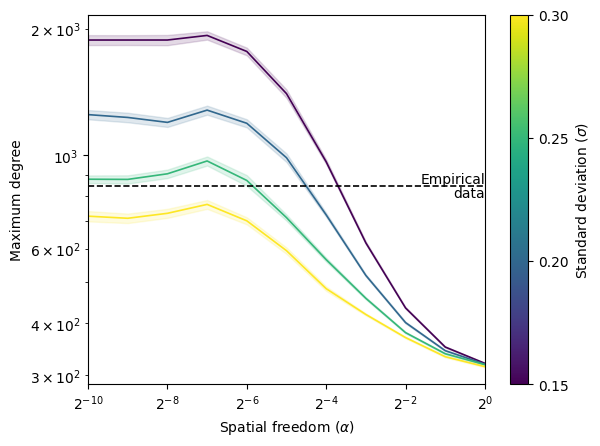

In [5]:

cmap = plt.cm.viridis
norm = Normalize(
    vmin=min(std_values),
    vmax=max(std_values),
)

fig, ax = plt.subplots()

for std in std_values:
    sub = df[df[std_col] == std].sort_values(alpha_col)

    alphas = sub[alpha_col].to_numpy()
    means = sub["mean_max_degree"].to_numpy()
    ses = sub["se_max_degree"].to_numpy()

    color = cmap(norm(std))

    ax.plot(
        alphas,
        means,
        color=color,
        linewidth=1.2,
        label=rf"$\sigma={std:g}$",
    )

    ax.fill_between(
        alphas,
        means - ses,
        means + ses,
        color=color,
        alpha=0.15,
    )

sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"Standard deviation ($\sigma$)")

# Show only the actual std values used
cbar.set_ticks(std_values)
cbar.set_ticklabels([f"{std:.2f}" for std in std_values])

# Log2 x-axis
ax.set_xscale("log", base=2)
ax.set_xlim(2**-10, 2**0)

tick_exponents = np.arange(-10, 1, 2)

ax.set_xticks(2.0 ** tick_exponents)
ax.set_xticklabels([
    rf"$2^{{{i}}}$"
    for i in tick_exponents
])

# Log10 y-axis
ax.set_yscale("log", base=10)

ax.axhline(
    844,
    color="black",
    linestyle="--",
    linewidth=1.2,
)

ax.text(
    1,
    844,
    "Empirical",
    va="bottom",
    ha="right",
    fontsize=10,
)

ax.text(
    1,
    844,
    "data",
    va="top",
    ha="right",
    fontsize=10,
)

ax.set_xlabel(r"Spatial freedom ($\alpha$)")
ax.set_ylabel("Maximum degree")

plt.savefig(
    "mean_max_degree_vs_alpha_by_std.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()